<a target="_blank" href="https://colab.research.google.com/github/fintech-dl-hse/course/blob/main/seminars/06_vae_gan/06_vae_gan.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# AE, VAE, GAN

## План семинара

1. **Recap** — свёрточные сети и мост к encoder/decoder.
1. **AutoEncoder** — архитектура, обучение, интерполяция в латентном пространстве.
1. **VAE** — вероятностная постановка, ELBO, reparametrization trick, реализация и сравнение с AE.
1. **GAN (DCGAN)** — adversarial training, генератор и дискриминатор, обучение.
1. **Pix2Pix и CycleGAN** — обзор conditional GAN и непарных данных.
1. **Метрики качества** — IS, FID.
1. **Генеративная трилемма** — обзор ограничений генеративных моделей.
1. **Блиц** — вопросы по материалу.
1. **Домашка** — обзор домашнего задания vae.

## Recap: от свёрток к encoder/decoder

На прошлых семинарах мы разобрали **свёрточные сети (CNN)**: свёртки извлекают локальные признаки, пулинг уменьшает пространственные размерности. Сегодня используем ту же идею в обратную сторону: **encoder** сжимает изображение в компактное представление (латент), **decoder** по латенту восстанавливает изображение. Такая схема лежит в основе автоэнкодеров и VAE.

## AutoEncoder

**Автоэнкодер** — модель из двух частей: **encoder** переводит вход в компактное представление (латент), **decoder** по латенту восстанавливает вход. Задача обучения — минимизировать **reconstruction loss** (например, MSE или L1 между входом и выходом). Узкое место между encoder и decoder (bottleneck) заставляет модель выделять главные признаки.

Классические автоэнкодеры ([Hinton & Salakhutdinov, 2006](https://www.cs.toronto.edu/~hinton/science.pdf)) использовались для предобучения и сжатия; сейчас их применяют для генерации (интерполяция в латенте), детекции аномалий и как часть более сложных моделей.

In [2]:
from torchvision.datasets import MNIST
import torchvision.transforms as transformsv1

import torch.nn as nn
from torch.optim import Adam
import torch
import torch.utils.data
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

In [3]:
transforms = transformsv1.Compose([
    transformsv1.ToTensor(),
])

mnist_dataset = MNIST("./MNIST", download=True, transform=transforms)

len(mnist_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


60000

In [4]:
class ImageEncoder(nn.Module):
    """Свёрточный encoder: изображение [B, 1, 28, 28] -> латент [B, latent_dim*14*14]."""

    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        self.sequential = nn.Sequential(*[
            nn.BatchNorm2d(1),
            nn.Conv2d(1, 64, kernel_size=3, padding=1),   # [ bs, 64, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # [ bs, 128, 28, 28 ]
            nn.MaxPool2d(2),                              # [ bs, 128, 14, 14 ]
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, self.latent_dim, kernel_size=1),     # [ bs, latent_dim, 14, 14 ]
            nn.Flatten(1),
        ])

    def forward(self, images_batch):
        return self.sequential(images_batch)


class ImageDecoder(nn.Module):
    """Свёрточный decoder: латент [B, latent_dim*14*14] -> изображение [B, 1, 28, 28]."""

    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        self.sequential = nn.Sequential(*[
            nn.Unflatten(1, (self.latent_dim, 14, 14)),
            nn.BatchNorm2d(self.latent_dim),
            nn.Conv2d(128, 64, kernel_size=1), # [ bs, 64, 14, 14 ]
            nn.Upsample([28, 28]),             # [ bs, 64, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 1, kernel_size=3, padding=1), # [ bs, 1, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(1),
            nn.Conv2d(1, 1, kernel_size=3, padding=1), # [ bs, 1, 28, 28 ]
            nn.Sigmoid(),
        ])

    def forward(self, image_embedding):
        # image_embedding ~ [ bs, 128 ]
        # print("image_embedding", image_embedding.shape)
        assert len(image_embedding.shape) == 2
        assert image_embedding.shape[1] == self.latent_dim * 14 * 14, f"{image_embedding.shape[1]} == {self.latent_dim}"
        # image_embedding = image_embedding.reshape(-1, self.latent_dim)
        return self.sequential(image_embedding)



In [5]:
class AutoEncoder(nn.Module):
    """Автоэнкодер: encoder + decoder, forward возвращает восстановленное изображение."""

    def __init__(self):
        super().__init__()

        self.encoder = ImageEncoder()
        self.decoder = ImageDecoder()

    def encode(self, images_batch):
        return self.encoder(images_batch)

    def decode(self, images_embeddings):
        return self.decoder(images_embeddings)

    def forward(self, images_batch):
        images_embeddings = self.encode(images_batch)
        # if self.training:
        #     images_embeddings += torch.randn_like(images_embeddings)
        return self.decode(images_embeddings)



In [6]:
mnist_dataset[0][0].shape

torch.Size([1, 28, 28])

In [7]:
AutoEncoder().forward( torch.rand( [ 5, 1, 28, 28 ] ) ).shape

torch.Size([5, 1, 28, 28])

In [8]:
def train(
    model: nn.Module,
    dataset: torch.utils.data.Dataset,
    loss_function: nn.Module,
    num_epochs: int = 10,
    device: str = "cuda",
    learning_rate: float = 3e-4,
) -> None:
    """
    Обучает модель (AE/VAE) на датасете с разделением на train/val.

    Args:
        model: Модель с forward(x) -> recon (и опционально mu, logvar для VAE).
        dataset: Датасет изображений.
        loss_function: Функция потерь (recon, x) или (recon, x, mu, logvar).
        num_epochs: Количество эпох.
        device: Устройство (cuda/cpu).
        learning_rate: Learning rate для Adam.
    """
    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1], generator=generator)
    model = model.to(device)

    optimizer = Adam(model.parameters(), lr=learning_rate)

    train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=100, shuffle=False)


    progress_bar = tqdm(range(num_epochs), total=num_epochs, desc="Epoch")
    for epoch_num in progress_bar:

        # train dataloader
        train_losses_sum = torch.tensor([0.0], device=device)
        train_iterations = 0
        for images_batch in train_dataloader:
            images_batch = images_batch[0].to(device)

            restored_images_batch = model(images_batch)

            loss = loss_function(restored_images_batch, images_batch)

            train_losses_sum += loss.detach()
            train_iterations += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # validation
        val_losses_sum = torch.tensor([0.0], device=device)
        valid_iterations = 0
        with torch.no_grad():
            for images_batch in val_dataloader:
                images_batch = images_batch[0].to(device)

                valid_iterations += 1
                restored_images_batch = model(images_batch)
                loss = loss_function(restored_images_batch, images_batch)

                val_losses_sum += loss.mean()

        mean_val_loss = (val_losses_sum / valid_iterations).item()
        mean_train_loss = (train_losses_sum / train_iterations).item()
        progress_bar.set_postfix({"val_loss": f"{mean_val_loss:.2f}", "train_loss": f"{mean_train_loss:.2f}"})
        # print(f"epoch {epoch_num} val_loss={mean_val_loss}")




In [9]:
autoencoder = AutoEncoder()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

generator = torch.Generator().manual_seed(42)

# cfair_dataset_5p, _ = torch.utils.data.random_split(cfair_dataset, [0.1, 0.9], generator=generator)
# print("cfair_dataset_5p", len(cfair_dataset_5p))
train(autoencoder, mnist_dataset, nn.L1Loss(), device=device, num_epochs=10, learning_rate=3e-4)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
@torch.no_grad()
def linear_latent_space_interpolation(
    model: nn.Module,
    image_from: torch.Tensor,
    image_to: torch.Tensor,
    device: str = "cpu",
    num_interpolation_steps: int = 10,
) -> list:
    """
    Строит линейную интерполяцию между двумя изображениями в латентном пространстве модели.

    Args:
        model: Модель с методами encode и decode.
        image_from: Исходное изображение (без batch).
        image_to: Конечное изображение.
        device: Устройство.
        num_interpolation_steps: Количество шагов интерполяции.

    Returns:
        Список массивов восстановленных изображений по шагам.
    """
    model.eval()
    image_from = image_from.unsqueeze(0).to(device)
    image_to = image_to.unsqueeze(0).to(device)
    model = model.to(device)

    latent_space_from = model.encode(image_from)
    latent_space_to = model.encode(image_to)

    latent_space_steps = torch.linspace(0, 1, num_interpolation_steps)

    latent_diff = latent_space_to - latent_space_from

    restored_images = []
    for latent_step_portion in latent_space_steps:
        latent_step = latent_diff * latent_step_portion
        latent_interpolation = latent_space_from + latent_step

        restored_image = model.decode(latent_interpolation).detach().clip(0, 1).cpu().numpy()[0]
        restored_images.append(restored_image)

    return restored_images

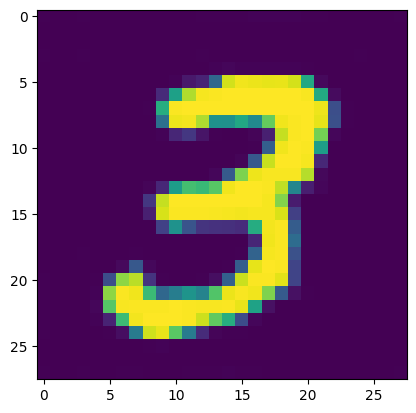

In [11]:
autoencoder.eval()
zero_autoencoder_prediction = autoencoder(mnist_dataset[7][0].unsqueeze(0).to(device))
plt.imshow(zero_autoencoder_prediction.permute(0, 2, 3, 1).detach().cpu().numpy()[0])

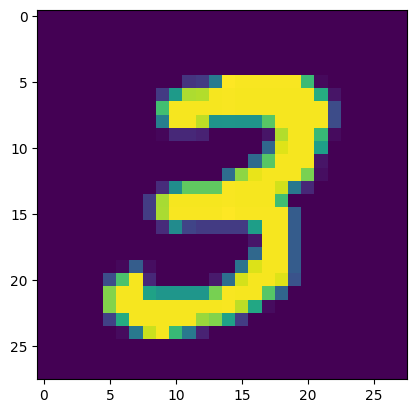

In [12]:
plt.imshow(mnist_dataset[7][0].permute(1,2, 0).numpy())

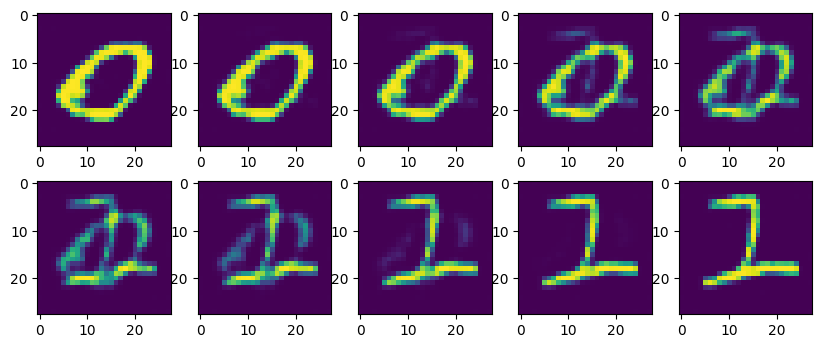

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

autoencoder_interpolated = linear_latent_space_interpolation(
    autoencoder, mnist_dataset[1][0], mnist_dataset[2][0],
    device=device,
    num_interpolation_steps=10
)

_, axs = plt.subplots(2, 5, figsize=(10, 4))
axs = axs.flatten()
for img, ax in zip(autoencoder_interpolated, axs):
    ax.imshow(img.T)
plt.show()

## VAE (Variational AutoEncoder) - Домашка

**Мотивация:** У обычного AE латентное пространство может быть «рваным»: близкие точки в латенте не обязательно дают похожие изображения. Генерация как сэмплирование из латента ненадёжна. **VAE** [Kingma & Welling, 2013](https://arxiv.org/abs/1312.6114) моделирует латент как случайную величину с нормальным распределением $q_\phi(z|x)$ (encoder выдаёт $\mu$ и $\log\sigma^2$), а декодер восстанавливает $x$ из $z$.

**ELBO:** Максимизируем нижнюю оценку правдоподобия (Evidence Lower BOund):

$$ \mathcal{L} = \mathbb{E}_{z \sim q_\phi(z|x)} \log p_\theta(x|z) - D_{KL}(q_\phi(z|x) \| p(z)) $$

Первый член — reconstruction loss (как в AE), второй — KL-дивергенция между $q_\phi(z|x)$ и априором $p(z) = \mathcal{N}(0, I)$. KL тянет латент к гладкому распределению.

**Reparametrization trick:** Сэмплирование $z \sim \mathcal{N}(\mu, \sigma^2)$ недифференцируемо по $\mu, \sigma$. Пишем $z = \mu + \sigma \cdot \epsilon$, где $\epsilon \sim \mathcal{N}(0, 1)$ — градиенты идут по $\mu$ и $\sigma$.

In [15]:
def reparametrize(mu: torch.Tensor, logvar: torch.Tensor, generator: torch.Generator | None = None) -> torch.Tensor:
    """
    Reparametrization trick: z = mu + sigma * epsilon, epsilon ~ N(0, 1).
    Позволяет backprop через сэмпл z по параметрам mu и logvar.

    Args:
        mu: Средние [B, latent_dim].
        logvar: Логарифм дисперсии [B, latent_dim].
        generator: Генератор для воспроизводимости.

    Returns:
        Сэмпл z [B, latent_dim], дифференцируемый по mu и logvar.
    """
    sigma = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(mu, generator=generator)
    return mu + sigma * epsilon


# Проверка: градиенты должны идти по mu и logvar
torch.manual_seed(42)
mu = torch.randn(2, 4, requires_grad=True)
logvar = torch.zeros(2, 4, requires_grad=True)
z = reparametrize(mu, logvar)
loss = z.sum()
loss.backward()
assert mu.grad is not None and logvar.grad is not None, "Градиенты по mu и logvar должны быть вычислены"
print("Reparametrization trick: градиенты по mu и logvar успешно вычислены.")
print("mu.grad norm:", mu.grad.norm().item())
print("logvar.grad norm:", logvar.grad.norm().item())

Reparametrization trick: градиенты по mu и logvar успешно вычислены.
mu.grad norm: 2.8284270763397217
logvar.grad norm: 1.342544436454773


---

## GAN: идея и adversarial training

**Generative Adversarial Network** [Goodfellow et al., 2014](https://arxiv.org/abs/1406.2661): две сети играют в игру. **Генератор** $G$ по шуму $z$ генерирует объект $G(z)$. **Дискриминатор** $D$ получает объект и предсказывает «реальный» или «сгенерированный». Цель $D$ — отличать реальные данные от сгенерированных; цель $G$ — обманывать $D$. Минимум по $G$ и максимум по $D$ от одной и той же величины даёт **min-max игру**:

$$ \min_G \max_D \; \mathbb{E}_{x \sim p_{data}} \log D(x) + \mathbb{E}_{z \sim p(z)} \log(1 - D(G(z))) $$

На практике поочерёдно делают шаг по $D$ (максимизировать правильность различения) и по $G$ (минимизировать вероятность, что $D$ распознает фейк). **DCGAN** [Radford et al., 2015](https://arxiv.org/abs/1511.06434) — та же идея, но генератор и дискриминатор реализованы свёрточными сетями (ConvTranspose в генераторе, Conv в дискриминаторе), что даёт стабильное обучение на изображениях.

## DCGAN

[Pytorch Tutorial](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)

In [16]:
#%matplotlib inline
from tqdm.auto import tqdm
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Set random seed for reproducibility
manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True) # Needed for reproducible results


Random Seed:  999


In [17]:
batch_size = 128

latent_dim_size = 100

generator_num_features = 64
discriminator_num_features = 64

num_epochs = 5

lr = 0.0002
beta1 = 0.5

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

image_transform = transforms.Compose([
    transforms.ToTensor(),
])

fm_dataset = FashionMNIST('./FashionMNIST', download=True, transform=image_transform)

dataloader = torch.utils.data.DataLoader(fm_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.8MB/s]


In [18]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m: nn.Module) -> None:
    """
    Инициализация весов для DCGAN: Conv — N(0, 0.02), BatchNorm — N(1, 0.02), bias=0.
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 and hasattr(m, 'weight'):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Dbg(nn.Module):
    def forward(self, tensor):
        print("tensor", tensor.shape)
        return tensor

### Generator

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/06_vae_gan/static/img_0.png" width=800 />

### Как `ConvTranspose2d` работает на практике (stride > 1)
Для ConvTranspose2d(kernel_size=3, stride=2) алгоритм такой:

1. Вставь нули между элементами входа — между каждыми соседними 2. значениями вставляется stride - 1 нулей. Вход 2×2 превращается в 3×3 (с нулями между).
3. Добавь padding вокруг (зависит от параметров).
4. Примени обычную свёртку с kernel 3×3, stride=1.


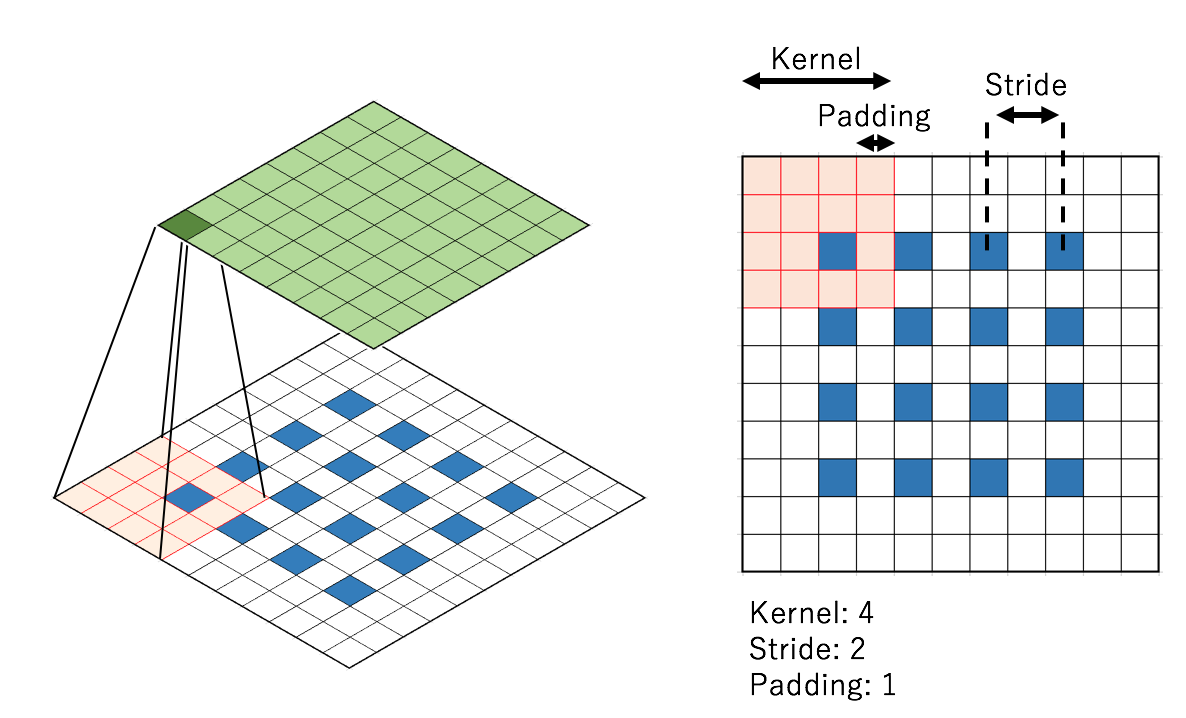


In [25]:
class GeneratorUpsampleConv(nn.Module):
    """Генератор DCGAN: Upsample + Conv. Вход: [B, latent_dim, 1, 1], выход: [B, 1, 28, 28]."""

    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input ~ [ bs, latent_dim_size, 1, 1 ]
            nn.Upsample( [ 7, 7 ] ), # [ bs, generator_num_features*8, 7, 7 ]
            nn.Conv2d(latent_dim_size, generator_num_features * 8, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Upsample( [ 14, 14 ] ), # [ bs, generator_num_features, 14, 14 ]
            nn.BatchNorm2d(generator_num_features * 8),
            nn.Conv2d(generator_num_features * 8, generator_num_features, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Upsample( [ 28, 28 ] ), # [ bs, generator_num_features, 28, 28 ]
            nn.BatchNorm2d(generator_num_features),
            nn.Conv2d(generator_num_features, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class GeneratorConvTranspose2d(nn.Module):
    """Генератор DCGAN на ConvTranspose2d. Вход: [B, latent_dim, 1, 1], выход: [B, 1, 28, 28]."""

    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input ~ [ bs, latent_dim_size, 1, 1 ]
            nn.ConvTranspose2d( latent_dim_size, generator_num_features * 8, kernel_size=7, bias=False), # [ bs, generator_num_features*8, 7, 7 ]
            nn.ReLU(True),
            nn.BatchNorm2d(generator_num_features * 8),
            nn.ConvTranspose2d(generator_num_features * 8, generator_num_features, kernel_size=4, stride=2, padding=1, bias=False), # ~ [ bs, generator_num_features, 14, 14 ]
            nn.ReLU(True),
            nn.BatchNorm2d(generator_num_features),
            nn.ConvTranspose2d( generator_num_features, 1, kernel_size=4, stride=2, padding=1, bias=False), # ~ [ bs, generator_num_features, 28, 28 ]
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [26]:
fm_dataset[0][0].shape

torch.Size([1, 28, 28])

In [27]:
netG = GeneratorUpsampleConv().to(device)
generated = netG( torch.rand([ 3, latent_dim_size, 1, 1 ]).to(device) )
assert generated.shape == torch.Size([3, 1, 28, 28])

In [28]:
netG = GeneratorConvTranspose2d().to(device)
generated = netG( torch.rand([ 3, latent_dim_size, 1, 1 ]).to(device) )
assert generated.shape == torch.Size([3, 1, 28, 28])

In [29]:
# Create the generator
# netG = GeneratorConvTranspose2d().to(device)
netG = GeneratorUpsampleConv().to(device)

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

netG( torch.rand([ 3, latent_dim_size, 1, 1 ]).to(device) ).shape

GeneratorUpsampleConv(
  (main): Sequential(
    (0): Upsample(size=[7, 7], mode='nearest')
    (1): Conv2d(100, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): Upsample(size=[14, 14], mode='nearest')
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Conv2d(512, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Upsample(size=[28, 28], mode='nearest')
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)


torch.Size([3, 1, 28, 28])

In [31]:
class Discriminator(nn.Module):
    """Дискриминатор DCGAN: свёртки с stride, выход — вероятность «реальное» [B, 1]."""

    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input ~ [ bs, 1, 28, 28 ]
            # Dbg(),
            nn.Conv2d(1, discriminator_num_features, kernel_size=4, stride=2, padding=1, bias=False), # ~ [ bs, discriminator_num_features, 14, 14 ]
            nn.LeakyReLU(0.2, inplace=True),
            # Dbg(),
            nn.Conv2d(discriminator_num_features, discriminator_num_features * 8, kernel_size=4, stride=2, padding=1, bias=False), # ~ [ bs, discriminator_num_features * 8, 7, 7 ]
            nn.BatchNorm2d(discriminator_num_features * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Dbg(),
            nn.Conv2d(discriminator_num_features * 8, 1, kernel_size=7, bias=False), # ~ [ bs, 1, 1, 1 ]
            nn.Flatten(1), # [ bs, 1 ]
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [32]:
# Create the Discriminator
netD = Discriminator().to(device)

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

netD.forward(next(iter(dataloader))[0].to(device)).shape

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(512, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Sigmoid()
  )
)


torch.Size([128, 1])

In [33]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()
# criterion = nn.CrossEntropyLoss()

# Create batch of latent vectors that we will use to visualize
# the progression of the generator
fixed_noise = torch.randn(64, latent_dim_size, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

netG = GeneratorConvTranspose2d().to(device)
# netG = GeneratorUpsampleConv().to(device) ## uncomment to test upsample + conv variant
netG.apply(weights_init)

netD = Discriminator().to(device)
netD.apply(weights_init)

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [35]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(tqdm(dataloader), 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################

        ## Train with all-real batch
        netD.zero_grad()

        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_images).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        D_x = output.mean().item()

        ## Train with all-fake batch

        # Generate batch of latent vectors
        noise = torch.randn(b_size, latent_dim_size, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        # Create a new label tensor for fake_label to avoid inplace modification
        label_fake = torch.full((b_size,), fake_label, dtype=torch.float, device=device)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label_fake)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        D_total_loss = (errD_real + errD_fake)
        D_total_loss.backward()

        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        # Create a new label tensor for real_label for generator cost
        label_gen = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label_gen)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...


  0%|          | 0/469 [00:00<?, ?it/s]

[0/5][0/469]	Loss_D: 1.9969	Loss_G: 2.1153	D(x): 0.7097	D(G(z)): 0.6383 / 0.2298
[0/5][50/469]	Loss_D: 0.0123	Loss_G: 5.9974	D(x): 0.9955	D(G(z)): 0.0070 / 0.0050
[0/5][100/469]	Loss_D: 0.0072	Loss_G: 6.2036	D(x): 0.9975	D(G(z)): 0.0045 / 0.0033
[0/5][150/469]	Loss_D: 0.1122	Loss_G: 4.9693	D(x): 0.9569	D(G(z)): 0.0430 / 0.0220
[0/5][200/469]	Loss_D: 0.0994	Loss_G: 4.1898	D(x): 0.9577	D(G(z)): 0.0494 / 0.0278
[0/5][250/469]	Loss_D: 0.0762	Loss_G: 4.6065	D(x): 0.9766	D(G(z)): 0.0482 / 0.0198
[0/5][300/469]	Loss_D: 3.6719	Loss_G: 9.4486	D(x): 0.9968	D(G(z)): 0.8371 / 0.0055
[0/5][350/469]	Loss_D: 0.0562	Loss_G: 4.1712	D(x): 0.9682	D(G(z)): 0.0202 / 0.0239
[0/5][400/469]	Loss_D: 0.0670	Loss_G: 4.0743	D(x): 0.9648	D(G(z)): 0.0253 / 0.0270
[0/5][450/469]	Loss_D: 0.0841	Loss_G: 4.1374	D(x): 0.9592	D(G(z)): 0.0285 / 0.0269


  0%|          | 0/469 [00:00<?, ?it/s]

[1/5][0/469]	Loss_D: 0.1031	Loss_G: 3.8720	D(x): 0.9572	D(G(z)): 0.0363 / 0.0350
[1/5][50/469]	Loss_D: 0.0654	Loss_G: 4.2147	D(x): 0.9757	D(G(z)): 0.0379 / 0.0231
[1/5][100/469]	Loss_D: 0.0572	Loss_G: 4.0820	D(x): 0.9722	D(G(z)): 0.0250 / 0.0267
[1/5][150/469]	Loss_D: 0.0641	Loss_G: 4.2735	D(x): 0.9688	D(G(z)): 0.0282 / 0.0239
[1/5][200/469]	Loss_D: 0.1524	Loss_G: 3.6036	D(x): 0.9175	D(G(z)): 0.0443 / 0.0534
[1/5][250/469]	Loss_D: 0.0516	Loss_G: 4.1959	D(x): 0.9849	D(G(z)): 0.0343 / 0.0244
[1/5][300/469]	Loss_D: 0.0505	Loss_G: 4.2274	D(x): 0.9774	D(G(z)): 0.0247 / 0.0282
[1/5][350/469]	Loss_D: 0.1175	Loss_G: 5.1229	D(x): 0.9927	D(G(z)): 0.0980 / 0.0086
[1/5][400/469]	Loss_D: 0.0756	Loss_G: 5.6142	D(x): 0.9912	D(G(z)): 0.0596 / 0.0084
[1/5][450/469]	Loss_D: 0.1296	Loss_G: 3.8621	D(x): 0.9399	D(G(z)): 0.0510 / 0.0444


...

[2/5][0/469]	Loss_D: 0.0982	Loss_G: 4.3442	D(x): 0.9241	D(G(z)): 0.0100 / 0.0211
[2/5][50/469]	Loss_D: 0.0881	Loss_G: 3.6773	D(x): 0.9514	D(G(z)): 0.0284 / 0.0420
[2/5][100/469]	Loss_D: 0.0772	Loss_G: 4.2158	D(x): 0.9716	D(G(z)): 0.0365 / 0.0305
[2/5][150/469]	Loss_D: 0.1476	Loss_G: 4.7661	D(x): 0.9881	D(G(z)): 0.1092 / 0.0144
[2/5][200/469]	Loss_D: 0.1114	Loss_G: 3.6004	D(x): 0.9426	D(G(z)): 0.0361 / 0.0464
[2/5][250/469]	Loss_D: 0.0940	Loss_G: 4.4575	D(x): 0.9486	D(G(z)): 0.0285 / 0.0216
[2/5][300/469]	Loss_D: 0.0871	Loss_G: 3.9291	D(x): 0.9647	D(G(z)): 0.0401 / 0.0359
[2/5][350/469]	Loss_D: 0.1563	Loss_G: 4.2823	D(x): 0.9673	D(G(z)): 0.0994 / 0.0288
[2/5][400/469]	Loss_D: 0.1448	Loss_G: 5.5385	D(x): 0.9901	D(G(z)): 0.1161 / 0.0075
[2/5][450/469]	Loss_D: 0.0922	Loss_G: 3.2411	D(x): 0.9546	D(G(z)): 0.0413 / 0.0739


  0%|          | 0/469 [00:00<?, ?it/s]

[3/5][0/469]	Loss_D: 0.0758	Loss_G: 4.4322	D(x): 0.9624	D(G(z)): 0.0334 / 0.0202
[3/5][50/469]	Loss_D: 0.1369	Loss_G: 3.8267	D(x): 0.9513	D(G(z)): 0.0663 / 0.0465
[3/5][100/469]	Loss_D: 7.9993	Loss_G: 8.6767	D(x): 0.9947	D(G(z)): 0.9843 / 0.0252
[3/5][150/469]	Loss_D: 0.0819	Loss_G: 3.6213	D(x): 0.9518	D(G(z)): 0.0272 / 0.0467
[3/5][200/469]	Loss_D: 0.1666	Loss_G: 4.0320	D(x): 0.9687	D(G(z)): 0.0951 / 0.0302
[3/5][250/469]	Loss_D: 0.0925	Loss_G: 3.5835	D(x): 0.9698	D(G(z)): 0.0562 / 0.0462
[3/5][300/469]	Loss_D: 0.1037	Loss_G: 4.7920	D(x): 0.9291	D(G(z)): 0.0177 / 0.0164
[3/5][350/469]	Loss_D: 0.0872	Loss_G: 3.9837	D(x): 0.9845	D(G(z)): 0.0659 / 0.0272
[3/5][400/469]	Loss_D: 0.1679	Loss_G: 2.6326	D(x): 0.8949	D(G(z)): 0.0369 / 0.1087
[3/5][450/469]	Loss_D: 0.1236	Loss_G: 4.1761	D(x): 0.9288	D(G(z)): 0.0306 / 0.0267


  0%|          | 0/469 [00:00<?, ?it/s]

[4/5][0/469]	Loss_D: 0.1312	Loss_G: 3.7244	D(x): 0.9316	D(G(z)): 0.0478 / 0.0464
[4/5][50/469]	Loss_D: 0.5370	Loss_G: 5.0102	D(x): 0.9833	D(G(z)): 0.3345 / 0.0573
[4/5][100/469]	Loss_D: 0.1036	Loss_G: 3.6464	D(x): 0.9673	D(G(z)): 0.0586 / 0.0455
[4/5][150/469]	Loss_D: 0.1362	Loss_G: 3.8208	D(x): 0.9579	D(G(z)): 0.0792 / 0.0325
[4/5][200/469]	Loss_D: 0.1340	Loss_G: 3.1133	D(x): 0.9264	D(G(z)): 0.0452 / 0.0626
[4/5][250/469]	Loss_D: 0.1048	Loss_G: 3.4683	D(x): 0.9592	D(G(z)): 0.0548 / 0.0470
[4/5][300/469]	Loss_D: 0.2430	Loss_G: 4.2705	D(x): 0.9576	D(G(z)): 0.1552 / 0.0364
[4/5][350/469]	Loss_D: 0.1503	Loss_G: 3.6423	D(x): 0.9222	D(G(z)): 0.0332 / 0.0373
[4/5][400/469]	Loss_D: 0.1896	Loss_G: 2.7924	D(x): 0.8568	D(G(z)): 0.0096 / 0.0962
[4/5][450/469]	Loss_D: 0.1672	Loss_G: 3.7338	D(x): 0.8866	D(G(z)): 0.0300 / 0.0425


### Кривые потерь и анимация генератора

Ниже — потери G и D во время обучения. Для сравнения архитектур генератора (Upsample+Conv vs ConvTranspose2d) перезапустите блок обучения, подставив другой класс генератора в `netG`.

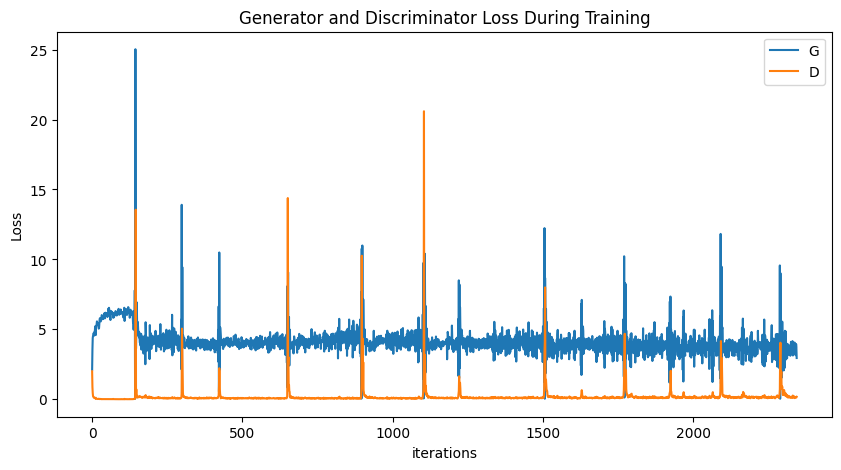

In [36]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

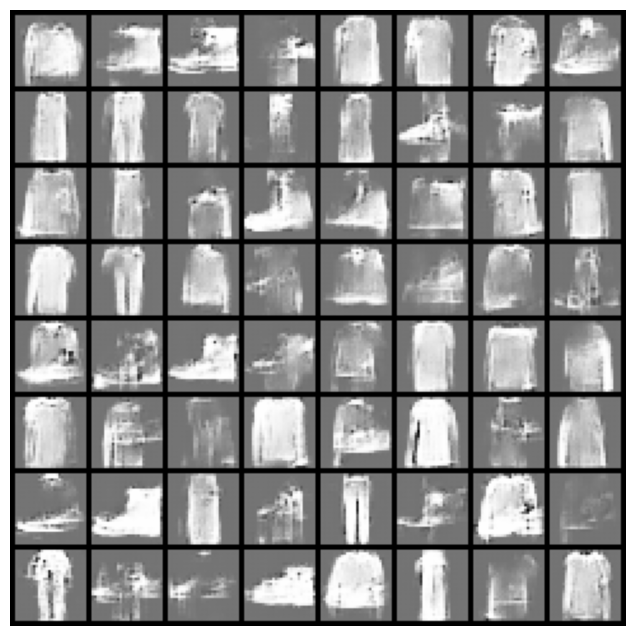

In [37]:
# upsample + conv
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

## Pix2Pix

[Paper](https://arxiv.org/abs/1611.07004)

[Demo](https://affinelayer.com/pixsrv/)


### Чем отличается от DCGAN?

- требует парных размеченных данных
- архитектурно UNet, т.к. теперь есть кондишн (контуры)


<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/06_vae_gan/static/img_1.png" width=800 />

In [ ]:
# https://github.com/eriklindernoren/PyTorch-GAN/blob/36d3c77e5ff20ebe0aeefd322326a134a279b93e/implementations/pix2pix/models.py#L15

class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_size),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))

        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)

        return x


class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(GeneratorUNet, self).__init__()

        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        # U-Net generator with skip connections from encoder to decoder
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)

        return self.final(u7)


**Обучение Pix2Pix:** генератор по контуру выдаёт изображение; лосс = GAN loss + $\lambda_{pixel}$ · L1(fake, real). Дискриминатор получает пару (изображение, контур) и учится отличать реальные пары от сгенерированных. Полные реализации: [PyTorch-GAN pix2pix](https://github.com/eriklindernoren/PyTorch-GAN/tree/master/implementations/pix2pix).

In [ ]:
# https://github.com/eriklindernoren/PyTorch-GAN/blob/master/implementations/pix2pix/pix2pix.py

dataloader = raise  NotImplemented()
optimizer_G = raise NotImplemented()
optimizer_D = raise NotImplemented()

lambda_pixel = 100

criterion_GAN = torch.nn.MSELoss()
criterion_pixelwise = torch.nn.L1Loss()

for epoch in range(10):
    for i, batch in enumerate(dataloader):

        # Model inputs
        edges = batch["edges"]
        images = batch["image"]

        # Adversarial ground truths
        valid = torch.tensor(np.ones((edges.size(0), *patch)))
        fake =  torch.tensor(np.zeros((edges.size(0), *patch)))

        optimizer_G.zero_grad()

        # GAN loss
        fake_images = generator(edges)
        pred_fake = discriminator(fake_images, edges)
        loss_GAN = criterion_GAN(pred_fake, valid)
        # Pixel-wise loss
        loss_pixel = criterion_pixelwise(fake_images, images)

        # Total loss
        loss_G = loss_GAN + lambda_pixel * loss_pixel

        loss_G.backward()

        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Real loss
        pred_real = discriminator(images, edges)
        loss_real = criterion_GAN(pred_real, valid)

        # Fake loss
        pred_fake = discriminator(fake_images.detach(), edges)
        # pred_fake = discriminator(fake_images.detach(), edges)
        loss_fake = criterion_GAN(pred_fake, fake)

        # Total loss
        loss_D = 0.5 * (loss_real + loss_fake)

        loss_D.backward()
        optimizer_D.step()

## CycleGAN

[Paper](https://arxiv.org/abs/1703.10593)

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/06_vae_gan/static/img_2.png" width=800 />

**Обучение CycleGAN:** два генератора $G_{AB}$, $G_{BA}$ и два дискриминатора $D_A$, $D_B$. Лоссы: GAN loss для каждой пары доменов, cycle consistency $\|G_{BA}(G_{AB}(A)) - A\|$ (и симметрично для B), optional identity loss. Парные данные не нужны. Полные реализации: [PyTorch-GAN cyclegan](https://github.com/eriklindernoren/PyTorch-GAN/tree/master/implementations/cyclegan).

In [ ]:
# Псевдокод обучения CycleGAN — см. описание выше и репозиторий PyTorch-GAN/cyclegan.

lambda_pixel = 100

criterion_GAN = torch.nn.MSELoss()
criterion_pixelwise = torch.nn.L1Loss()



for epoch in range(10):
    for i, batch in enumerate(dataloader):

        # Set model input
        real_A = batch["A"]
        real_B = batch["B"]

        # Adversarial ground truths
        valid = torch.ones((real_A.size(0), *D_A.output_shape))
        fake = torch.zeros((real_A.size(0), *D_A.output_shape))

        # ------------------
        #  Train Generators
        # ------------------

        G_AB.train() # G_AB.trainig == True
        G_BA.train()

        G_BA.zero_grad()
        G_AB.zero_grad()

        # Identity loss
        loss_id_A = criterion_identity(G_BA(real_A), real_A)
        loss_id_B = criterion_identity(G_AB(real_B), real_B)

        loss_identity = (loss_id_A + loss_id_B) / 2

        # GAN loss
        fake_B = G_AB(real_A)
        loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
        fake_A = G_BA(real_B)
        loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)

        loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2

        # Cycle loss
        recov_A = G_BA(fake_B)
        loss_cycle_A = criterion_cycle(recov_A, real_A)
        recov_B = G_AB(fake_A)
        loss_cycle_B = criterion_cycle(recov_B, real_B)

        loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

        # Total loss
        loss_G = loss_GAN + opt.lambda_cyc * loss_cycle + opt.lambda_id * loss_identity

        loss_G.backward()
        optimizer_G.step()

        # -----------------------
        #  Train Discriminator A
        # -----------------------

        optimizer_D_A.zero_grad()

        # Real loss
        loss_real = criterion_GAN(D_A(real_A), valid)
        # Fake loss (on batch of previously generated samples)
        loss_fake = criterion_GAN(D_A(fake_A_.detach()), fake)
        # Total loss
        loss_D_A = (loss_real + loss_fake) / 2

        loss_D_A.backward()
        optimizer_D_A.step()

        # -----------------------
        #  Train Discriminator B
        # -----------------------

        optimizer_D_B.zero_grad()

        # Real loss
        loss_real = criterion_GAN(D_B(real_B), valid)
        # Fake loss (on batch of previously generated samples)
        loss_fake = criterion_GAN(D_B(fake_B_.detach()), fake)
        # Total loss
        loss_D_B = (loss_real + loss_fake) / 2

        loss_D_B.backward()
        optimizer_D_B.step()

        loss_D = (loss_D_A + loss_D_B) / 2


## Оценка качества сгенерированных данных

Для оценки качества моделек, отслеживания переобучения нам для всех задач и всегда хочется иметь автоматизированные метрики качества.

### Требования:

- метрика должна работать независимо от количества классов
- без дополнительной разметки человеком


### 📊 Сравнение IS и FID

| | **Inception Score (IS)** | **Fréchet Inception Distance (FID)** |
|---|---|---|
| **Что оценивает** | Разнообразие и узнаваемость (по классам) | Близость распределений сгенерированных и реальных изображений в пространстве фичей |
| **Вход** | Логиты/вероятности классов (softmax) | Фичи предпоследнего слоя Inception |
| **Направление** | 🔺 Выше — лучше | 🔻 Ниже — лучше |
| **Учитывает реальные данные** | ❌ Нет (только сгенерированные) | ✅ Да (сравнение с эталоном) |
| **Типичное использование** | Быстрая оценка «качества» без референса | Сравнение моделей по одной датасете; чаще предпочитают в статьях |

### Inception Score (IS)

[Paper - Improved Techniques for Training GANs](https://arxiv.org/pdf/1606.03498) (Section 4. Assessment of image quality)

### Интуиция и предпосылки:

1) Если на изображении есть валидный объект, классификатор должен быть достаточно уверенно определить его

> Images that contain meaningful objects should have a conditional label distribution p(y|x) with low entropy.

2) Мы хотим чтобы сеть генерировала объекты разных классов, поэтому хотим максимизировать дисперсию

> Moreover, we expect the model to generate varied images, so the marginal ∫ p(y|x = G(z))dz should have high entropy

### Формула

- $p(y|x)$ — распределение классов (softmax) для изображения $x$ по предобученному классификатору.
- $p(y) = \mathbb{E}_{x \sim G}[p(y|x)]$ — маргинальное распределение по сгенерированным изображениям.

Inception Score — экспонента от среднего KL-дивергенции между условным и маргинальным распределениями:

$$ \mathrm{IS} = \exp\left( \mathbb{E}_{x \sim G}\left[ \mathrm{KL}\bigl( p(y|x) \,\|\, p(y) \bigr) \right] \right) $$

Эквивалентно через энтропии: $\mathrm{IS} = \exp\bigl( H(p(y)) - \mathbb{E}_x[H(p(y|x))] \bigr)$ — выше, когда маргинал разнообразный ($H(p(y))$ велика), а предсказания уверенные ($H(p(y|x))$ мала).

### Какие значения принимает?

> The inception score has a lowest value of 1.0 and a highest value of the number of classes supported by the classification model; in this case, the Inception v3 model supports the 1,000 classes -->

[Источник](https://machinelearningmastery.com/how-to-implement-the-inception-score-from-scratch-for-evaluating-generated-images/)


In [ ]:
# Источник https://github.com/sbarratt/inception-score-pytorch/blob/master/inception_score.py
# TODO то псевдокод

import numpy as np
from torchvision.models.inception import inception_v3

def get_predictions(inception_model, x):
    up = nn.Upsample(size=(299, 299), mode='bilinear')
    x = up(x)
    prediction_logits = inception_model(x)
    return F.softmax(prediction_logits).cpu().numpy()

@torch.no_grad()
def inception_score(inception_model, generated_data, splits=10):
    N = len(generated_data)
    dataloader = DataLoader(generated_data, batch_size=1000)

    preds = np.zeros([ N, num_classes ])
    for i, batch in enumerate(dataloader):
        batch_size_i = batch.shape[0]

        preds[i*batch_size:i*batch_size + batch_size_i] = get_predictions(inception_model, batch)

    # Now compute the mean kl-div
    split_scores = []

    for k in range(splits):
        part = preds[k * (N // splits): (k+1) * (N // splits), :]
        p_y = torch.mean(part, axis=0)
        scores = []
        for i in range(part.shape[0]):
            p_yx = part[i, :]
            # todo make calculations stable
            scores.append(np.sum(p_yx * np.log(p_yx / p_y)))

        split_scores.append(np.exp(np.mean(scores)))

    return np.mean(split_scores), np.std(split_scores)

inception_model = inception_v3()
is_mean, is_std = inception_score(inception_model, dataloader)

### Frechet Inception Distance (FID)


Paper - [GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium](https://arxiv.org/abs/1706.08500)

### Интуиция и предпосылки:

1) IS работает на уровне распределений вероятностей классов

2) Можно спуститься на уровень ниже и использовать скрытые фича-мапы с последнего уровня Inception

3) В отличие от IS принимает на вход целевые данные для вычисления распределения в реальных данных

### Как работает?

1) Получаем фича-мапы с последнего слоя

2) Вычисляем статистики

$$ F(N_b, N_e) = ‖ \mu_b - \mu_e ‖^2 + tr(\Sigma_b + \Sigma_e - 2\sqrt{\Sigma_b\Sigma_e}) $$

3) Авторы утверждают, что FID лучше улавливает похожесть сгенерированных изображений с реальными данными

--

PS кстати, для оценки генерации аудио есть аналогичная метрика - `FAD` ([Frechet audio distance](https://arxiv.org/pdf/1812.08466))


### Какие значения может принимать?


$$
[ 0, \inf )
$$

In [ ]:
# Pseudocode
# https://github.com/mseitzer/pytorch-fid/blob/master/src/pytorch_fid/fid_score.py#L281

def calculate_fid_given_paths(paths, batch_size):

    model = InceptionV3().to(device)

    m1, s1 = compute_statistics_of_path(
        paths[0], model, batch_size, dims, device, num_workers
    )
    m2, s2 = compute_statistics_of_path(
        paths[1], model, batch_size, dims, device, num_workers
    )
    fid_value = (mu1 - mu2).pow(2) + np.trace( s1 + s2 - 2 * np.sqrt( s1 @ s2 ) )

    return fid_value


### Генеративная трилемма

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/06_vae_gan/static/img_4.png" width=400 />

[источник](https://developer.nvidia.com/blog/improving-diffusion-models-as-an-alternative-to-gans-part-1/)

## Блиц

### VAE

#### ❓ **Вопрос**: Чем `AutoEncoder` отличается от `VariationalAutoEncoder`? Какая мотивация?

<details>

<summary><strong>Ответ</strong></summary>

VAE задаёт латент как распределение (обычно гауссово) и обучается с ELBO: reconstruction + KL-регуляризация к $p(z)$. Из-за этого латентное пространство становится более гладким и непрерывным — интерполяция и сэмплирование дают осмысленные объекты. У обычного AE латент не регуляризован, «дыры» между кодами могут давать артефакты. Генерация в VAE: сэмплируем $z \sim \mathcal{N}(0, I)$ и прогоняем через декодер.</br>

</details>


#### ❓ **Вопрос**: Как можно использовать `AutoEncoder` для задачи поиска аномалий? Какой из вариантов автоэнкодера для этого лучше всего подходит?

<details>

<summary><strong>Ответ</strong></summary>

Смотрим на ошибку декодера. Если декодер плохо восстанавливает данные, значит этого сэмпла не было в исходной выборке, на которой мы обучились, и это скорее всего выброс.</br>

</details>


#### ❓ **Вопрос**: Автоэнкодеры — это генеративная модель? Можно ли запустить генерацию чего-либо через автоэнкодеры? Как ей управлять?

<details>

<summary><strong>Ответ</strong></summary>

Да, можно. Управлять генерацией можно через интерполяцию в латентном пространстве или сэмплирование из латента (в VAE — сэмплируем $z \sim \mathcal{N}(0, I)$ и подаём в декодер).</br>

</details>


#### ❓ **Вопрос**: Какие метрики качества можно использовать во время обучения автоэнкодеров?

<details>

<summary><strong>Ответ</strong></summary>

FID, IS (Inception Score). Обе метрики используют фичи/предсказания предобученной сети (Inception) и не требуют ручной разметки.</br>

</details>


#### ❓ **Вопрос**: Что такое reparametrization trick? Какую проблему он решает?

<details>

<summary><strong>Ответ</strong></summary>

Решает проблему распространения градиентов.</br>
Если мы просто сэмплируем из распределения с заданными параметрами — не понятно, как распространять градиенты.</br>

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/06_vae_gan/static/img_3.png" width=400 /></br>

</details>


---

### VQ-VAE

#### ❓ **Вопрос**: Зачем в VQ-VAE нужен straight-through estimator? Что бы произошло, если бы мы просто подставили в декодер квантизованный латент $z_q$ без этой уловки?

<details>

<summary><strong>Ответ</strong></summary>

Операция выбора ближайшего кода (argmin) не дифференцируема — градиент по индексу не определён. Без straight-through градиент от reconstruction loss не проходил бы в энкодер, и мы не могли бы обучать энкодер. Straight-through «обманывает» backward: мы копируем градиент с $z_q$ на $z_e$, как будто $z_q = z_e$, поэтому энкодер получает полезный градиент и учится выдавать латент, который после квантизации даёт хорошую реконструкцию.</br>

</details>

### GAN

#### ❓ **Вопрос**: Чем по сути является дискриминатор в процессе обучения GAN?

<details>

<summary><strong>Ответ</strong></summary>

Дискриминатор можно интерпретировать как обучаемый лосс.</br>

</details>


#### ❓ **Вопрос**: Зачем нам нужно 2 оптимизатора во время обучения GAN?

<details>

<summary><strong>Ответ</strong></summary>

Потому что у нас 2 модели — дискриминатор и генератор.</br>

</details>


#### ❓ **Вопрос**: В чём сложность Pix2Pix подхода?

<details>

<summary><strong>Ответ</strong></summary>

Они требуют размеченных парных данных — их не всегда легко найти и разметить.</br>

</details>


#### ❓ **Вопрос**: Что будет, если убрать `.detach()` в месте вычисления фейковой составляющей для дискриминатора?

```python
        # Optimize generator
        fake_images = generator(edges)
        # ...

        # Optimize discriminator

        # Fake loss
        pred_fake = discriminator(fake_images.detach(), edges)
        ...
```

<details>

<summary><strong>Ответ</strong></summary>

На самом деле ничего не сломается. Просто градиенты потекут на генератор. Но т.к. перед оптимизацией генератора мы зануляем градиенты — это не сломает обучение. Однако процесс тренировки будет требовать больше памяти.</br>

</details>


#### ❓ **Вопрос**: Какие проблемы есть в обучении GAN?

<details>

<summary><strong>Ответ</strong></summary>

- Нестабильное обучение</br>
- mode collapse — генератор обучается обманывать дискриминатор, а не воспроизводить исходное распределение</br>

</details>


#### ❓ **Вопрос**: В чём преимущества CycleGAN по сравнению с Pix2Pix?

<details>

<summary><strong>Ответ</strong></summary>

CycleGAN не требует размеченных пар картинок.</br>

</details>


#### ❓ **Вопрос**: Как измерить качество сгенерированных картинок?

<details>

<summary><strong>Ответ</strong></summary>

FID / IS — метрики, построенные на оценке распределений в пространстве фича-мап.</br>

</details>


#### ❓ **Вопрос**: Как вычисляется IS?

<details>

<summary><strong>Ответ</strong></summary>

На основе распределения вероятностей предсказанных классов. Пример реальных данных для вычисления не нужен.</br>

</details>


#### ❓ **Вопрос**: На основе чего вычисляется FID?

<details>

<summary><strong>Ответ</strong></summary>

На основе активаций промежуточных слоёв Inception. Сравниваются распределения гауссиан реальных данных и сгенерированных.</br>

</details>


#### ❓ **Вопрос**: Что лучше использовать — IS или FID?

<details>

<summary><strong>Ответ</strong></summary>

На практике обычно смотрят сразу обе метрики.</br>

</details>


#### ❓ **Вопрос**: Верно ли, что если сделать `model.eval()`, градиенты для такой модели не вычисляются? Чтобы градиенты вычислялись, надо вызвать `.train()`?

<details>

<summary><strong>Ответ</strong></summary>

Обе части вопроса неверны. `train()`/`eval()` влияют на работу Dropout/BatchNorm слоёв. На вычисление градиентов эти методы не влияют.</br>

Чтобы отключить вычисление градиентов, можно использовать контекстный менеджер:</br>
- `with torch.no_grad()`</br>
- декоратор `@torch.no_grad()`</br>
- пройтись по параметрам модели и выключить флаг `.requires_grad`: `p.requires_grad = False` для `p in model.parameters()`</br>

</details>


## Домашка: vae

В домашнем задании **vae** нужно реализовать и обучить VAE на датасете (например, MNIST или другом по условию).

**На что обратить внимание:**
- Корректная реализация reparametrization trick и лосса (reconstruction + KL).
- Стабильность обучения: баланс между reconstruction и KL (иногда весят KL коэффициентом $\beta$).
- Проверка генерации: сэмплирование $z \sim \mathcal{N}(0, I)$ и визуализация выходов декодера.
